**OBJECTIVES**

To perform Unsupervised Machine Learning (K-Means Clustering) to segment the patient population into distinct behavioral personas. By grouping patients based on demographics, clinical history (medication/diagnosis), and financial profiles, the clinic can design targeted intervention strategies for each group.

In [2]:
# mount drive to import csv files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import used libraries

import pandas as pd                                       # for data tables [DataFrames]
import matplotlib.pyplot as plt                           # foundation for charts
import seaborn as sns                                     # for professional looking charts
import numpy as np                                        # handles the heavy math
import warnings                                           # Suppress all warnings
warnings.filterwarnings('ignore')

# Scikit-Learn: the "brain" of the operation

from sklearn.cluster import KMeans                       # unsupervised learner that groups patients with close-groups
from sklearn.preprocessing import StandardScaler         # slustering specialist used different data sizes to remove biases

In [4]:
# loading all CSV files

patients = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/patients.csv")
appointments = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/appointments.csv")
billing = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/billing.csv")
diagnoses = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/diagnoses.csv")
doctors = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/doctors.csv")
medications = pd.read_csv("/content/drive/MyDrive/Tableau Datasets/medications.csv")

In [5]:
# using appointment table as my Anchor Table

healthcare_df = appointments.copy()

In [6]:
# merging tables together using left joins so no appointment is missing

healthcare_df = healthcare_df.merge(patients, on="patient_id", how="left")
healthcare_df = healthcare_df.merge(doctors, on="doctor_id", how="left")
healthcare_df = healthcare_df.merge(billing, on="appointment_id", how="left")
healthcare_df = healthcare_df.merge(diagnoses, on="appointment_id", how="left")

In [7]:
# medication is grouped by patient_id and counted by med_id as one patient can have multiple medications

med_agg = medications.groupby("patient_id").agg({
    "med_id": "count"
}).rename(columns={"med_id": "num_medication"}).reset_index()

In [8]:
# merging the medication count into the main anchor table

healthcare_df = healthcare_df.merge(med_agg, on="patient_id", how="left")

In [9]:
# creating columns for age using appointment_date - date_of_birth

healthcare_df['date_of_birth'] = pd.to_datetime(healthcare_df['date_of_birth'])           # conveting date_of_birth to datetime to calculate time differences

healthcare_df['appointment_date'] = pd.to_datetime(healthcare_df['appointment_date'])     # # conveting appointment_date to datetime to calculate time differences

healthcare_df['age'] = (healthcare_df['appointment_date'] - healthcare_df['date_of_birth']).dt.days // 365

In [10]:
# age binning for deeper insight [creating a logical life-stage groups]

bin = [0, 18, 35, 60, 100]
label =['Child', 'Young Adult', 'Adult', 'Senior']

# create a new age_group column

healthcare_df['age_group'] = pd.cut(healthcare_df['age'], bins=bin, labels=label)
healthcare_df.head()

,appointment_id,patient_id,doctor_id,appointment_date,status,visit_reason,first_name,last_name,gender,date_of_birth,...,bill_id,amount,insurance_covered,patient_paid,diagnosis_id,diagnosis_code,diagnosis_description,num_medication,age,age_group
0,1,907,44,2025-07-08,Completed,Key current shoulder.,Margaret,Burns,F,1941-06-10,...,655.0,483.0,160.0,323.0,NaN,NaN,NaN,1.0,84,Senior
1,1,907,44,2025-07-08,Completed,Key current shoulder.,Margaret,Burns,F,1941-06-10,...,13754.0,370.0,261.0,109.0,NaN,NaN,NaN,1.0,84,Senior
2,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,1947.0,198.0,197.0,1.0,NaN,NaN,NaN,1.0,55,Adult
3,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,3586.0,372.0,230.0,142.0,NaN,NaN,NaN,1.0,55,Adult
4,2,1911,66,2025-06-29,Completed,Sense huge benefit.,Joshua,Montgomery,F,1970-06-07,...,15239.0,562.0,537.0,25.0,NaN,NaN,NaN,1.0,55,Adult


In [11]:
# create the target in the main DF

healthcare_df['target'] = healthcare_df['status'].apply(lambda x: 0 if x == 'Completed' else 1)

In [12]:
# aggregate data by patient

patient_profiles = healthcare_df.groupby('patient_id').agg({
    'age': 'first',                             # age stays the same for a patient
    'num_medication': 'mean',                   # average meds they take
    'insurance_covered': 'mean',                # average financial support
    'target': 'mean'                            # No-Show rate
}).reset_index()

# rename target to 'no_show_rate'

patient_profiles.rename(columns={'target': 'no_show_rate'}, inplace=True)

patient_profiles.head()

,patient_id,age,num_medication,insurance_covered,no_show_rate
0,1,4,NaN,86.750000,0.600000
1,2,36,3.0,156.250000,0.000000
2,3,42,NaN,175.142857,1.000000
3,4,67,2.0,264.250000,1.000000
4,5,17,1.0,65.000000,0.857143


In [13]:
# DataFrame Exploration [is_null column summation]

patient_profiles.isnull().sum()

,0
patient_id,0
age,0
num_medication,986
insurance_covered,405
no_show_rate,0


In [14]:
# filling missing values with the median of each column

patient_profiles['num_medication'] = patient_profiles['num_medication'].fillna(patient_profiles['num_medication'].median())

patient_profiles['insurance_covered'] = patient_profiles['insurance_covered'].fillna(patient_profiles['insurance_covered'].median())
patient_profiles

,patient_id,age,num_medication,insurance_covered,no_show_rate
0,1,4,2.0,86.750000,0.600000
1,2,36,3.0,156.250000,0.000000
2,3,42,2.0,175.142857,1.000000
3,4,67,2.0,264.250000,1.000000
4,5,17,1.0,65.000000,0.857143
...,...,...,...,...,...
4916,4996,28,3.0,167.000000,0.500000
4917,4997,60,2.0,429.000000,1.000000
4918,4998,59,1.0,140.000000,0.750000
4919,4999,85,2.0,180.000000,0.500000


In [15]:
# DataFrame Exploration [confirms is_null column summation]

patient_profiles.isnull().sum()

,0
patient_id,0
age,0
num_medication,0
insurance_covered,0
no_show_rate,0


In [16]:
# Scaling the data

# pick the features that define a "Persona"

features = ['age', 'num_medication', 'insurance_covered', 'no_show_rate']
X_cluster = patient_profiles[features]

# scaling for K-Means

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [17]:
# calculate the 'Stress Score' [WCSS - Within-Cluster Sum of Squares] for 1 to 10 clusters

wcss = []                   # creates an empty list to store the 'Stress Scores' for each attempt
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)                        # inertia_ is the python name for WCSS

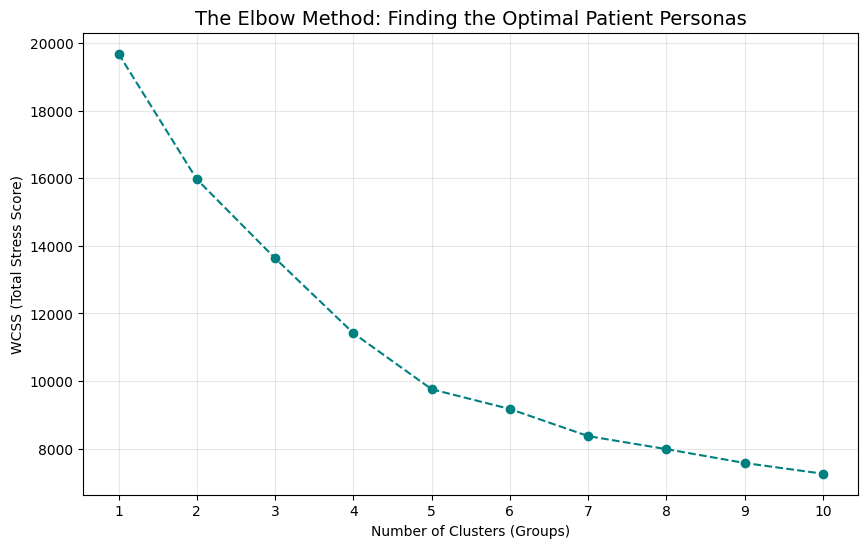

In [18]:
# plotting the elbow

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', color='teal', linestyle='--')
plt.title('The Elbow Method: Finding the Optimal Patient Personas', fontsize=14)
plt.xlabel('Number of Clusters (Groups)')
plt.ylabel('WCSS (Total Stress Score)')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Based on the Elbow Chart, 5 is the "Point of Diminishing Returns"

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

# fit model and save the labels to our patient_profiles DF

patient_profiles['cluster'] = kmeans.fit_predict(X_scaled)
patient_profiles.head()

,patient_id,age,num_medication,insurance_covered,no_show_rate,cluster
0,1,4,2.0,86.750000,0.600000,0
1,2,36,3.0,156.250000,0.000000,1
2,3,42,2.0,175.142857,1.000000,0
3,4,67,2.0,264.250000,1.000000,4
4,5,17,1.0,65.000000,0.857143,0


In [20]:
# check how many patients are in each group

patient_profiles['cluster'].value_counts()

,count
cluster,
0,1333
4,1307
1,960
3,677
2,644


In [21]:
# calculate the average of each feature for our 5 new groups

persona_summary = patient_profiles.groupby('cluster')[features].mean()
print("--- PATIENT PERSONA SUMMARY ---")
persona_summary

--- PATIENT PERSONA SUMMARY ---


,age,num_medication,insurance_covered,no_show_rate
cluster,,,,
0,18.931733,1.613653,179.916328,0.774120
1,47.096875,1.785417,183.723072,0.248899
2,44.063665,1.925466,325.267026,0.705307
3,43.098966,3.787297,185.791380,0.711899
4,69.951033,1.670237,175.812835,0.803071


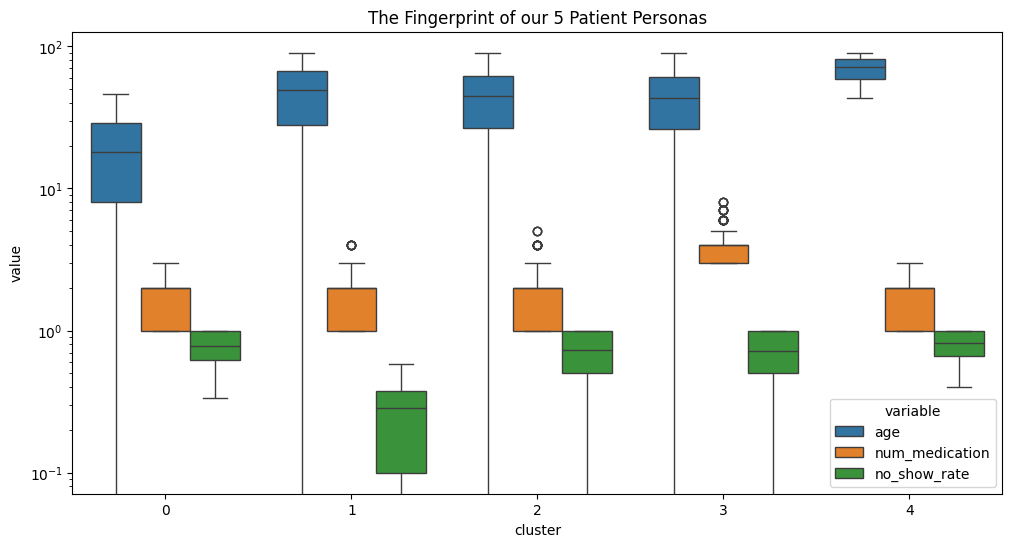

In [22]:
# melt data for plotting

df_melted = patient_profiles.melt(id_vars='cluster', value_vars=['age', 'num_medication', 'no_show_rate'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='cluster', y='value', hue='variable')
plt.title('The Fingerprint of our 5 Patient Personas')
plt.yscale('log')                                             # helps with the difference between age and no_show_rate
plt.show()

In [23]:
# define descriptive names for the different personas

persona_names ={
    0: 'Entry-Level Risk',
    1: 'Golden Standard',
    2: 'Mid-Life Ghost',
    3: 'High-Intensity Priority',
    4: 'Vulnerable Seniors'
}

# create a new persona_profile column

patient_profiles['persona_profile'] = patient_profiles['cluster'].map(persona_names)
patient_profiles.head()

,patient_id,age,num_medication,insurance_covered,no_show_rate,cluster,persona_profile
0,1,4,2.0,86.750000,0.600000,0,Entry-Level Risk
1,2,36,3.0,156.250000,0.000000,1,Golden Standard
2,3,42,2.0,175.142857,1.000000,0,Entry-Level Risk
3,4,67,2.0,264.250000,1.000000,4,Vulnerable Seniors
4,5,17,1.0,65.000000,0.857143,0,Entry-Level Risk
